# Практическая работа №2
# "Logistic regression & SVM"



> @Гришина Ксения, 23.Б16-мм



## 📒 Полный текст задания
(из файла с дз, дублирую для удобства)

> Практическая работа № 2

> Ваша задача будет попробовать использовать логистическую регрессию и методы опорных векторов на данных, которые Вы выбрали.
> 1. Теоретическая справка: цель работы, задачи работы, используемые алгоритмы – необходимо небольшое описание алгоритмов.
2. Обработать данные (взять 1 лабораторную работу), но здесь уже добавляется проверка на дисбаланс классов, на корреляцию признаков и корреляцию с целевой переменной (см. Практическую работу 5). Ваша задача сделать анализ и обработать данные так, чтобы получить максимальную точность.
3. Использовать логистическую регрессию (достаточно одного метода, но необходимо обосновать почему именно его).
4. Использовать методы опорных векторов (достаточно выбор одного ядра, но обосновать почему именно его – использование всех ядер и описание выводов по ним будет считать как доп. задание и возможно получить до 2 до баллов).
5. Ко всем методам необходимо попробовать подобрать вручную гиперпараметры, можно просто поменять и посмотреть результат. Это должен быть отдельный блок кода, где Вы поменяли параметры модели, получили метрику качества и сделали выводы почему точность изменилась или почему не изменилась.
6. Основные метрики качества проверки: F1-score (по обоим/всем классам) и Accuracy, можно использовать больше, если хочется.
7. Сделать понятные, четкие выводы по каждому алгоритму, по каждому использованному методу (name.info() и тд можно не комментировать, главное сделать выводы, связанные с новым методом)

> Работа должна представлять собой ноутбук в GoogleCollab или Kagle (ссылка), оставленный комментарием напротив Вашей фамилии и даты выдачи работ. Также, ноутбук должен быть только с доступом просмотра к моей почте (!!!). Почта: o.gavrilenko.r@gmail.com

> Замечание: если будет использован GPT (как копипаст), то работа не будет засчитана. Если Вы предоставляете работу с использованием GPT - кода и это вычисляется, но это не полностью копипаст, то будет снижено 50% баллов. GPT можно использовать как источник информации, но это не должно быть скопировано и неосмысленно отправлено на проверку.

> P.S.: Проверяйте открытые доступы к моему аккаунту, иначе работа не будет засчитана, как сданная.

> ДД данной работы: 30.09.2025 до 23:59

## ∀ Импорты

In [ ]:
import os
from google.colab import drive

import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

from sklearn.svm import SVC

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

## 1 Теоретическая справка
<!--
Теоретическая справка: цель работы, задачи работы, используемые алгоритмы – необходимо небольшое описание алгоритмов. -->

**Цель работы** - Использовать логистическую регрессию и метод опорных векторов к данным о продаже видеоигр.

**Задачи работы**:

- Определить признак для классификации(по продажам видеоигр(всего 2 класса))
1) Применить метод Логистической регрессии для этой задачи.
2) Применить Метод опорных векторов для этой задачи.

**Используемые алгоритмы:**
- Логистическая регрессия (*биномиальная*)
- Метод опорных векторов SVM (*SVC*) (+2 доп за все ядра)


> Небольшое описание алгоритмов:

> 1. Логистическая регрессия — это метод классификации, который предсказывает вероятность принадлежности объекта к классу.
> - Для бинарной классификации используется `sigmoid`. Для мультиномиальной(и порядковой?) используется `softmax`.
> - Модель обучается методом максимального правдоподобия и подбирает такие коэффициенты, чтобы вероятность правильно разделяла классы.
> - Хорошо работает на линейно разделимых данных.

> 2. Метод опорных векторов — это алгоритм классификации, который ищет оптимальную гиперплоскость, разделяющую классы с максимальным зазором (`margin`).
> - Для нелинейных случаев применяется ядро (`kernel trick`): данные переносятся в пространство большей размерности.
> - Основные ядра: `linear`, `rbf`, `poly`, `sigmoid`.
> - Работает и для линейных, и для нелинейных данных.


## 2 Обработка данных

 <!-- Обработать данные (взять 1 лабораторную работу), но здесь уже добавляется проверка на дисбаланс классов, на корреляцию признаков и корреляцию с целевой переменной (см. Практическую работу 5). Ваша задача сделать анализ и обработать данные так, чтобы получить максимальную точность. -->

### a) Частичный повтор практической работы №1

#### 1 Теоретическая справка

Для поиска своего набора данных воспользовалась поиском в [kaggle](https://www.kaggle.com/datasets/ibriiee/video-games-sales-dataset-2022-updated-extra-feat). Выбрала такой датасет о продажах видеоигр
(https://www.kaggle.com/datasets/ibriiee/video-games-sales-dataset-2022-updated-extra-feat)

На kaggle дали такое описание данным:



> Этот набор данных предоставляет актуальную информацию о продажах и популярности различных видеоигр по всему миру. Данные включают название, платформу, год выпуска, жанр, издателя и данные о продажах в Северной Америке, Европе, Японии и других регионах. Он также содержит оценки и рейтинги критиков и пользователей, включая средний рейтинг критиков, количество просмотренных игр, средний рейтинг пользователей, количество просмотренных игр, разработчика и рейтинг. Этот всеобъемлющий и важный набор данных предоставляет ценную информацию о мировом рынке видеоигр и является незаменимым инструментом для геймеров, профессионалов отрасли и исследователей рынка.



Записей: 16719.

**Признаки**(16 шт):
| Название колонки | Описание |
|------------------|----------|
| Name             | Название видеоигры |
| Platform         | Платформа, на которой была выпущена игра (PlayStation, Xbox, Nintendo и др.) |
| Year of Release  | Год выпуска игры |
| Genre            | Жанр видеоигры (экшен, приключения, спорт и др.) |
| Publisher        | Компания, выпустившая игру |
| NA Sales         | Продажи игры в Северной Америке (в млн USD) |
| EU Sales         | Продажи игры в Европе (в млн USD) |
| JP Sales         | Продажи игры в Японии (в млн USD) |
| Other Sales      | Продажи игры в других регионах (в млн USD) |
| Global Sales     | Общие мировые продажи игры (в млн USD) |
| Critic Score     | Средняя оценка игры от профессиональных критиков (0-100)|
| Critic Count     | Количество критиков, оценивших игру |
| User Score       | Средняя оценка игры от пользователей (0-10)|
| User Count       | Количество пользователей, оценивших игру |
| Developer        | Компания, разработавшая игру |
| Rating           | Возрастной рейтинг игры (ESRB, PEGI и др.) |


На этих данных можно выполнять **задачи**:
- первичный анализ данных (есть пропуски и некорректные типы данных)
- регрессии (наиболее естественная, предсказать Global_Sales)
- классификации (например, по жанру, рейтингу или платформе)
- кластеризации (группировать схожие игры)

**Задача на эту работу** - первичный анализ данных.
по содержанию ноутбука будет видно, какие шаги для этого потребовалось выполнить.

#### 2 Датасет

- Датасет индивидуален, был привязан ко мне комментарием в табличке курса

Считаем скачанный датасет

In [ ]:
# 1. Добавлять напрямую, так делала в работе №1
# data = pd.read_csv('Video_Games.csv')

# 2. через mount. Это удобнее, так делаю в работе №2
# Соединяем Google Drive к Collab
gdrive_dir = '/content/drive/'
drive.mount(gdrive_dir, force_remount = True)

# Считываем датасет
data = pd.read_csv('/content/drive/MyDrive/ML-SPbU-HW/Video_Games.csv')

Mounted at /content/drive/


Проверим корректность считывания файла и попробуем посмотреть первые записи.

In [ ]:
data.head()

,Name,Platform,Year_of_Release,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Critic_Score,Critic_Count,User_Score,User_Count,Developer,Rating
0,Wii Sports,Wii,2006.0,Sports,Nintendo,41.36,28.96,3.77,8.45,82.53,76.0,51.0,8,322.0,Nintendo,E
1,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24,NaN,NaN,NaN,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.68,12.76,3.79,3.29,35.52,82.0,73.0,8.3,709.0,Nintendo,E
3,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.61,10.93,3.28,2.95,32.77,80.0,73.0,8,192.0,Nintendo,E
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37,NaN,NaN,NaN,NaN,NaN,NaN


Все успешно подгрузилось.
- Заметим, что в данных **есть пропуски, как количественые, так и категориальные признаки**

Также, сразу узнаем основную информацию о датафрейме "по факту"

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16719 entries, 0 to 16718
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             16717 non-null  object 
 1   Platform         16719 non-null  object 
 2   Year_of_Release  16450 non-null  float64
 3   Genre            16717 non-null  object 
 4   Publisher        16665 non-null  object 
 5   NA_Sales         16719 non-null  float64
 6   EU_Sales         16719 non-null  float64
 7   JP_Sales         16719 non-null  float64
 8   Other_Sales      16719 non-null  float64
 9   Global_Sales     16719 non-null  float64
 10  Critic_Score     8137 non-null   float64
 11  Critic_Count     8137 non-null   float64
 12  User_Score       10015 non-null  object 
 13  User_Count       7590 non-null   float64
 14  Developer        10096 non-null  object 
 15  Rating           9950 non-null   object 
dtypes: float64(9), object(7)
memory usage: 2.0+ MB


- Видим, что **есть неправильные типы данных** (многочисленные `object`-ы, `'Year_of_Release'` типа `float`)

**Вывод**: датасет согласуется с требованиями (не самый чистый).

#### 3 Обработка пропусков

из инфо выше видно, что у двух записей не хватает названия игры. можно предположить, что данные там некорректно собирались, и по логике их можно удалить.

In [ ]:
# Удаляем строки, где Name пустое
data = data.dropna(subset=['Name'])

Заполним медианой год выпуска

In [ ]:
# Числовые признаки заполним медианой (устойчива к выбросам)
data['Year_of_Release'] = data['Year_of_Release'].fillna(data['Year_of_Release'].median())

Заполним модой издателя

In [ ]:
# Категориальные признаки заполним модой
data['Publisher'] = data['Publisher'].fillna(data['Publisher'].mode()[0])

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 16717 entries, 0 to 16718
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             16717 non-null  object 
 1   Platform         16717 non-null  object 
 2   Year_of_Release  16717 non-null  float64
 3   Genre            16717 non-null  object 
 4   Publisher        16717 non-null  object 
 5   NA_Sales         16717 non-null  float64
 6   EU_Sales         16717 non-null  float64
 7   JP_Sales         16717 non-null  float64
 8   Other_Sales      16717 non-null  float64
 9   Global_Sales     16717 non-null  float64
 10  Critic_Score     8137 non-null   float64
 11  Critic_Count     8137 non-null   float64
 12  User_Score       10015 non-null  object 
 13  User_Count       7590 non-null   float64
 14  Developer        10096 non-null  object 
 15  Rating           9950 non-null   object 
dtypes: float64(9), object(7)
memory usage: 2.2+ MB


для признаков, связанных с оценками очень много пропусков (~8к). удалив их мы потеряем половину датасета, а заполнив медианой придется учитывать, что мы могли исказить исходное распределение.



In [ ]:
data['Critic_Score'].unique()

array([76., nan, 82., 80., 89., 58., 87., 91., 61., 97., 95., 77., 88.,
       83., 94., 93., 85., 86., 98., 96., 90., 84., 73., 74., 78., 92.,
       71., 72., 68., 62., 49., 67., 81., 66., 56., 79., 70., 59., 64.,
       75., 60., 63., 69., 50., 25., 42., 44., 55., 48., 57., 29., 47.,
       65., 54., 20., 53., 37., 38., 33., 52., 30., 32., 43., 45., 51.,
       40., 46., 39., 34., 35., 41., 36., 28., 31., 27., 26., 19., 23.,
       24., 21., 17., 22., 13.])

In [ ]:
# Числовые признаки заполним медианой (устойчива к выбросам)
data['Critic_Score'] = data['Critic_Score'].fillna(data['Critic_Score'].median())
data['Critic_Count'] = data['Critic_Count'].fillna(data['Critic_Count'].median())

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 16717 entries, 0 to 16718
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             16717 non-null  object 
 1   Platform         16717 non-null  object 
 2   Year_of_Release  16717 non-null  float64
 3   Genre            16717 non-null  object 
 4   Publisher        16717 non-null  object 
 5   NA_Sales         16717 non-null  float64
 6   EU_Sales         16717 non-null  float64
 7   JP_Sales         16717 non-null  float64
 8   Other_Sales      16717 non-null  float64
 9   Global_Sales     16717 non-null  float64
 10  Critic_Score     16717 non-null  float64
 11  Critic_Count     16717 non-null  float64
 12  User_Score       10015 non-null  object 
 13  User_Count       7590 non-null   float64
 14  Developer        10096 non-null  object 
 15  Rating           9950 non-null   object 
dtypes: float64(9), object(7)
memory usage: 2.2+ MB


In [ ]:
# при попытке заполнить пропуски вышла ошибка, посмотрим какие значения принимает этот признак
data['User_Score'].unique()

array(['8', nan, '8.3', '8.5', '6.6', '8.4', '8.6', '7.7', '6.3', '7.4',
       '8.2', '9', '7.9', '8.1', '8.7', '7.1', '3.4', '5.3', '4.8', '3.2',
       '8.9', '6.4', '7.8', '7.5', '2.6', '7.2', '9.2', '7', '7.3', '4.3',
       '7.6', '5.7', '5', '9.1', '6.5', 'tbd', '8.8', '6.9', '9.4', '6.8',
       '6.1', '6.7', '5.4', '4', '4.9', '4.5', '9.3', '6.2', '4.2', '6',
       '3.7', '4.1', '5.8', '5.6', '5.5', '4.4', '4.6', '5.9', '3.9',
       '3.1', '2.9', '5.2', '3.3', '4.7', '5.1', '3.5', '2.5', '1.9', '3',
       '2.7', '2.2', '2', '9.5', '2.1', '3.6', '2.8', '1.8', '3.8', '0',
       '1.6', '9.6', '2.4', '1.7', '1.1', '0.3', '1.5', '0.7', '1.2',
       '2.3', '0.5', '1.3', '0.2', '0.6', '1.4', '0.9', '1', '9.7'],
      dtype=object)

In [ ]:
tbd_count = (data['User_Score'] == 'tbd').sum()
print(f"Количество 'tbd': {tbd_count}")

Количество 'tbd': 2425


In [ ]:
# Преобразуем в числа, нечисловые значения станут NaN
data['User_Score'] = pd.to_numeric(data['User_Score'], errors='coerce')
# Заполним их медианой
data['User_Score'] = data['User_Score'].fillna(data['User_Score'].median())

# Проверка
data['User_Score'].unique()

array([8. , 7.5, 8.3, 8.5, 6.6, 8.4, 8.6, 7.7, 6.3, 7.4, 8.2, 9. , 7.9,
       8.1, 8.7, 7.1, 3.4, 5.3, 4.8, 3.2, 8.9, 6.4, 7.8, 2.6, 7.2, 9.2,
       7. , 7.3, 4.3, 7.6, 5.7, 5. , 9.1, 6.5, 8.8, 6.9, 9.4, 6.8, 6.1,
       6.7, 5.4, 4. , 4.9, 4.5, 9.3, 6.2, 4.2, 6. , 3.7, 4.1, 5.8, 5.6,
       5.5, 4.4, 4.6, 5.9, 3.9, 3.1, 2.9, 5.2, 3.3, 4.7, 5.1, 3.5, 2.5,
       1.9, 3. , 2.7, 2.2, 2. , 9.5, 2.1, 3.6, 2.8, 1.8, 3.8, 0. , 1.6,
       9.6, 2.4, 1.7, 1.1, 0.3, 1.5, 0.7, 1.2, 2.3, 0.5, 1.3, 0.2, 0.6,
       1.4, 0.9, 1. , 9.7])

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 16717 entries, 0 to 16718
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             16717 non-null  object 
 1   Platform         16717 non-null  object 
 2   Year_of_Release  16717 non-null  float64
 3   Genre            16717 non-null  object 
 4   Publisher        16717 non-null  object 
 5   NA_Sales         16717 non-null  float64
 6   EU_Sales         16717 non-null  float64
 7   JP_Sales         16717 non-null  float64
 8   Other_Sales      16717 non-null  float64
 9   Global_Sales     16717 non-null  float64
 10  Critic_Score     16717 non-null  float64
 11  Critic_Count     16717 non-null  float64
 12  User_Score       16717 non-null  float64
 13  User_Count       7590 non-null   float64
 14  Developer        10096 non-null  object 
 15  Rating           9950 non-null   object 
dtypes: float64(10), object(6)
memory usage: 2.2+ MB


In [ ]:
data['User_Score'] = data['User_Score'].fillna(data['User_Score'].median())
data['User_Count'] = data['User_Count'].fillna(data['User_Count'].median())

Так как пропуски в этих признаках есть в почти половине записей, заполнять стат методами мы можем изменить распределение. Создадим новую категорию, чтобы не искажать исходные данные.

In [ ]:
# заполняем пропуски в рейтинге значением "неизвестно"
data["Rating"] = data["Rating"].fillna("Unknown")
data["Developer"] = data["Developer"].fillna("Unknown")

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 16717 entries, 0 to 16718
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             16717 non-null  object 
 1   Platform         16717 non-null  object 
 2   Year_of_Release  16717 non-null  float64
 3   Genre            16717 non-null  object 
 4   Publisher        16717 non-null  object 
 5   NA_Sales         16717 non-null  float64
 6   EU_Sales         16717 non-null  float64
 7   JP_Sales         16717 non-null  float64
 8   Other_Sales      16717 non-null  float64
 9   Global_Sales     16717 non-null  float64
 10  Critic_Score     16717 non-null  float64
 11  Critic_Count     16717 non-null  float64
 12  User_Score       16717 non-null  float64
 13  User_Count       16717 non-null  float64
 14  Developer        16717 non-null  object 
 15  Rating           16717 non-null  object 
dtypes: float64(10), object(6)
memory usage: 2.2+ MB


**Вывод**: заполнили пропуски, стараясь сохранить реальность данных и применимость к основным задачам датасета

#### 4 Обработка выбросов

Для начала, было бы неплохо узнать, есть ли они вообще. Для этого посмотрим на Q3 и max в инфо или на боксплотах.

In [ ]:
data.describe()

,Year_of_Release,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Critic_Score,Critic_Count,User_Score,User_Count
count,16717.000000,16717.000000,16717.000000,16717.000000,16717.000000,16717.000000,16717.000000,16717.000000,16717.00000,16717.000000
mean,2006.497218,0.263255,0.145010,0.077610,0.047333,0.533462,70.010767,23.609380,7.32976,86.760364
std,5.830342,0.813475,0.503303,0.308836,0.186721,1.547956,9.776915,13.510184,1.02779,384.399216
min,1980.000000,0.000000,0.000000,0.000000,0.000000,0.010000,13.000000,3.000000,0.00000,4.000000
25%,2003.000000,0.000000,0.000000,0.000000,0.000000,0.060000,71.000000,21.000000,7.50000,24.000000
50%,2007.000000,0.080000,0.020000,0.000000,0.010000,0.170000,71.000000,21.000000,7.50000,24.000000
75%,2010.000000,0.240000,0.110000,0.040000,0.030000,0.470000,71.000000,21.000000,7.50000,24.000000
max,2020.000000,41.360000,28.960000,10.220000,10.570000,82.530000,98.000000,113.000000,9.70000,10665.000000


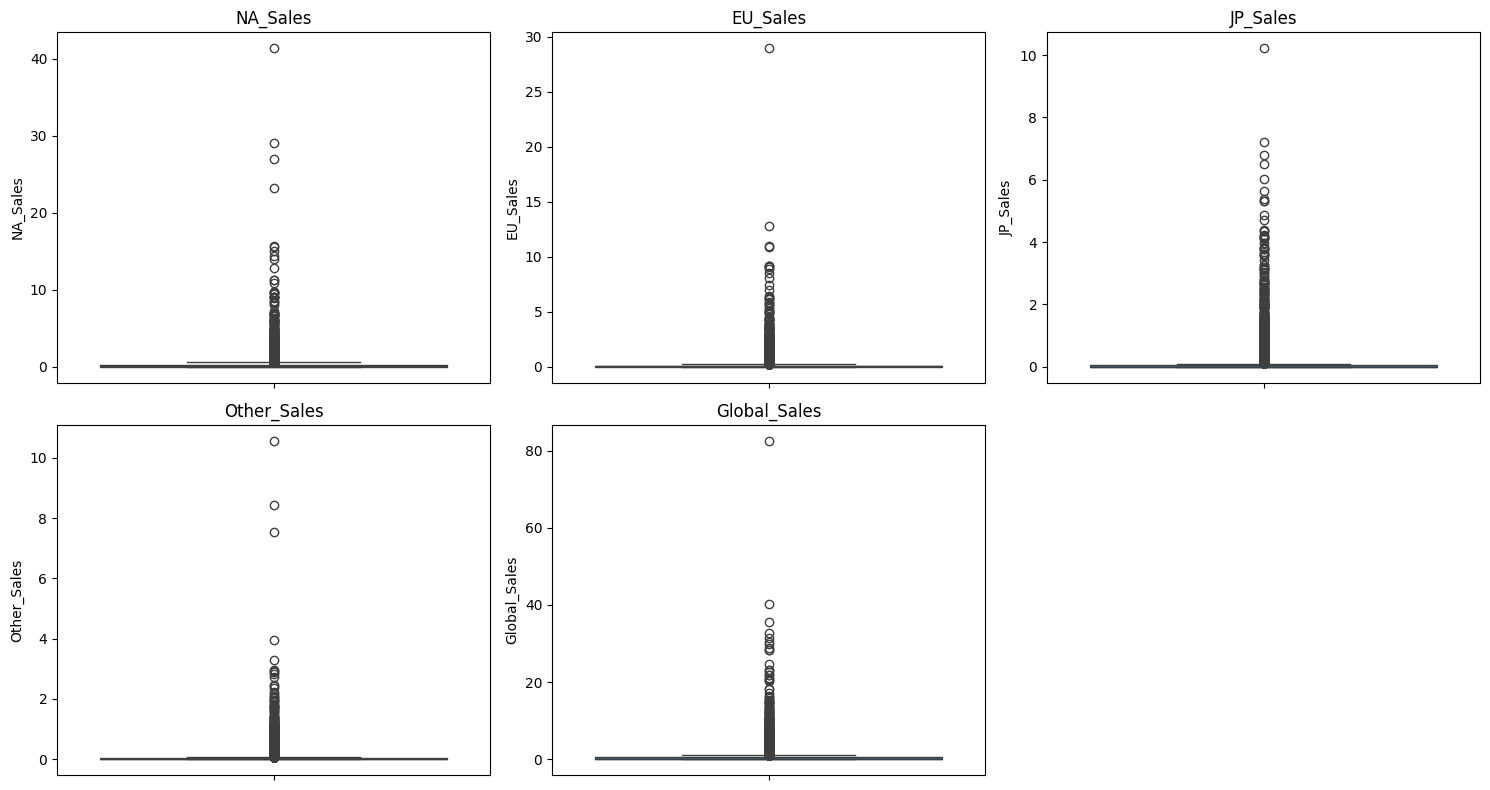

In [ ]:
# Список столбцов продаж
sales_cols = ['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales', 'Global_Sales']

plt.figure(figsize=(15, 8))

# Проходим по каждому столбцу и строим боксплот
for i, col in enumerate(sales_cols, 1):
    plt.subplot(2, 3, i)  # создаём сетку 2x3
    sns.boxplot(y=data[col])
    plt.title(col)

plt.tight_layout()
plt.show()

Выяснили, что наши данные очень асимметричны, т е что есть и очень успешные игры, с продажами сильно выше среднего, и провальные проекты. Но в основном у нас не совсем так, поэтому на них можно смотреть как на выбросы. (Зависит от задачи.)

Прологарифмировав данные мы можем избавиться от тяжелых хвостов и сделать их более симметричными.

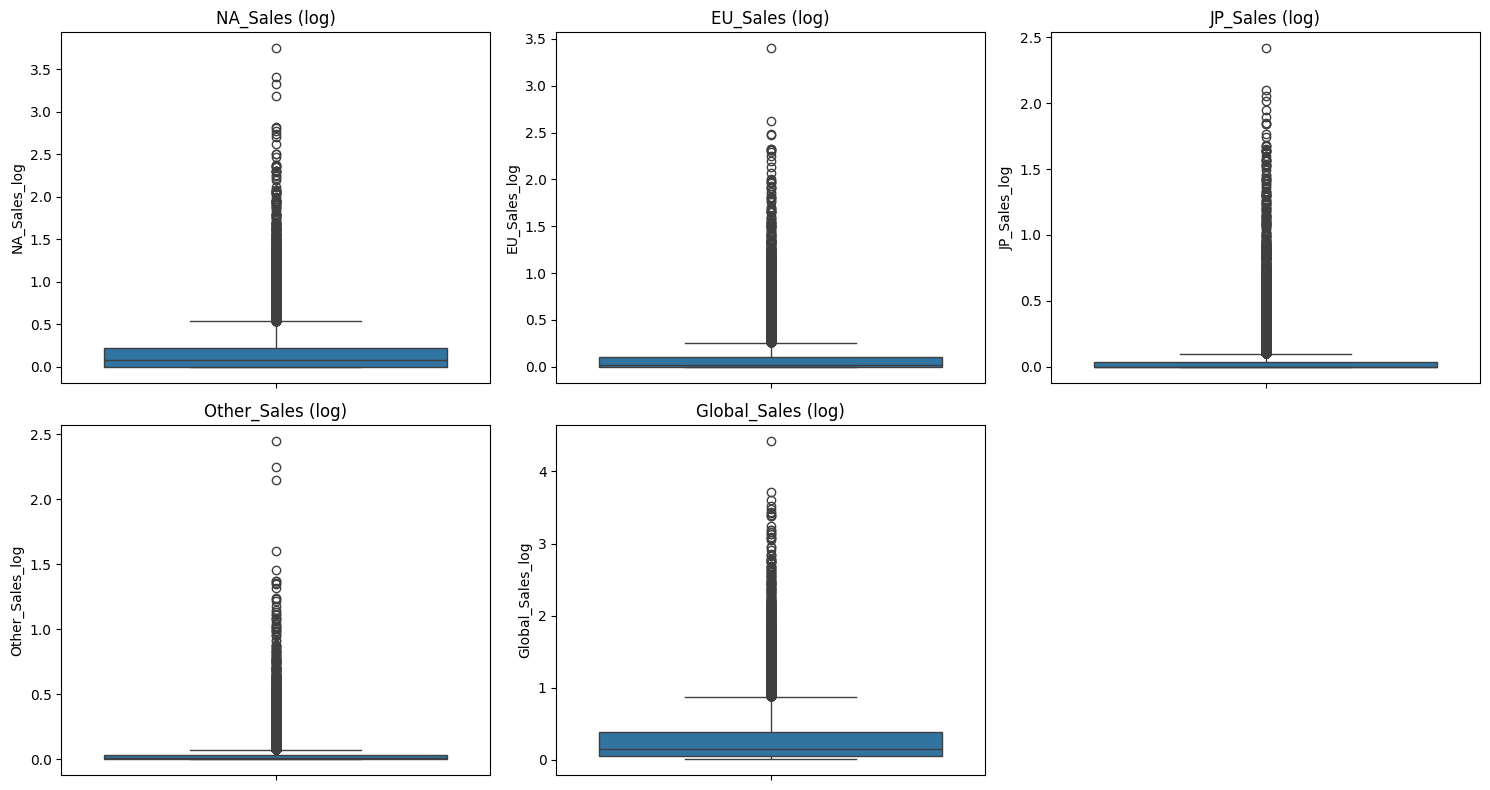

In [ ]:
# создаём логарифмированные столбцы
for col in sales_cols:
    data[col + '_log'] = np.log1p(data[col])

# визуализация
plt.figure(figsize=(15, 8))
for i, col in enumerate(sales_cols, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(y=data[col + '_log'])
    plt.title(col + ' (log)')

plt.tight_layout()
plt.show()

При использовании межквартильного размаха для удаления выбросов мы потреяем большую часть данных(~6k).

In [ ]:
sales_log_cols = ['NA_Sales_log', 'EU_Sales_log', 'JP_Sales_log', 'Other_Sales_log', 'Global_Sales_log']

for col in sales_log_cols:
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    # оставляем только строки без выбросов
    data = data[(data[col] >= lower) & (data[col] <= upper)]

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10671 entries, 3882 to 16718
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Name              10671 non-null  object 
 1   Platform          10671 non-null  object 
 2   Year_of_Release   10671 non-null  float64
 3   Genre             10671 non-null  object 
 4   Publisher         10671 non-null  object 
 5   NA_Sales          10671 non-null  float64
 6   EU_Sales          10671 non-null  float64
 7   JP_Sales          10671 non-null  float64
 8   Other_Sales       10671 non-null  float64
 9   Global_Sales      10671 non-null  float64
 10  Critic_Score      10671 non-null  float64
 11  Critic_Count      10671 non-null  float64
 12  User_Score        10671 non-null  float64
 13  User_Count        10671 non-null  float64
 14  Developer         10671 non-null  object 
 15  Rating            10671 non-null  object 
 16  NA_Sales_log      10671 non-null  float64


In [ ]:
# Был другой вариант: Чтобы не удалять столько записей,
# и терять хитов индустрии, можно было их обработать - подрезать
# экстремальные значения сверху и снизу на до границ IQR. Так хиты останутся,
# но их значения будут не так разбросаны. Боксплоты будут вообще без выбросов.

# я решила так не делать, так как на мой взгляд это сильно искажает
# реальную картину, но может это не так.


# # sales_cols = ['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales', 'Global_Sales']

# for col in sales_cols:
#     lower = data[col].quantile(0.25)
#     upper = data[col].quantile(0.75)
#     data[col] = data[col].clip(lower, upper)

# print(data[sales_cols].describe())

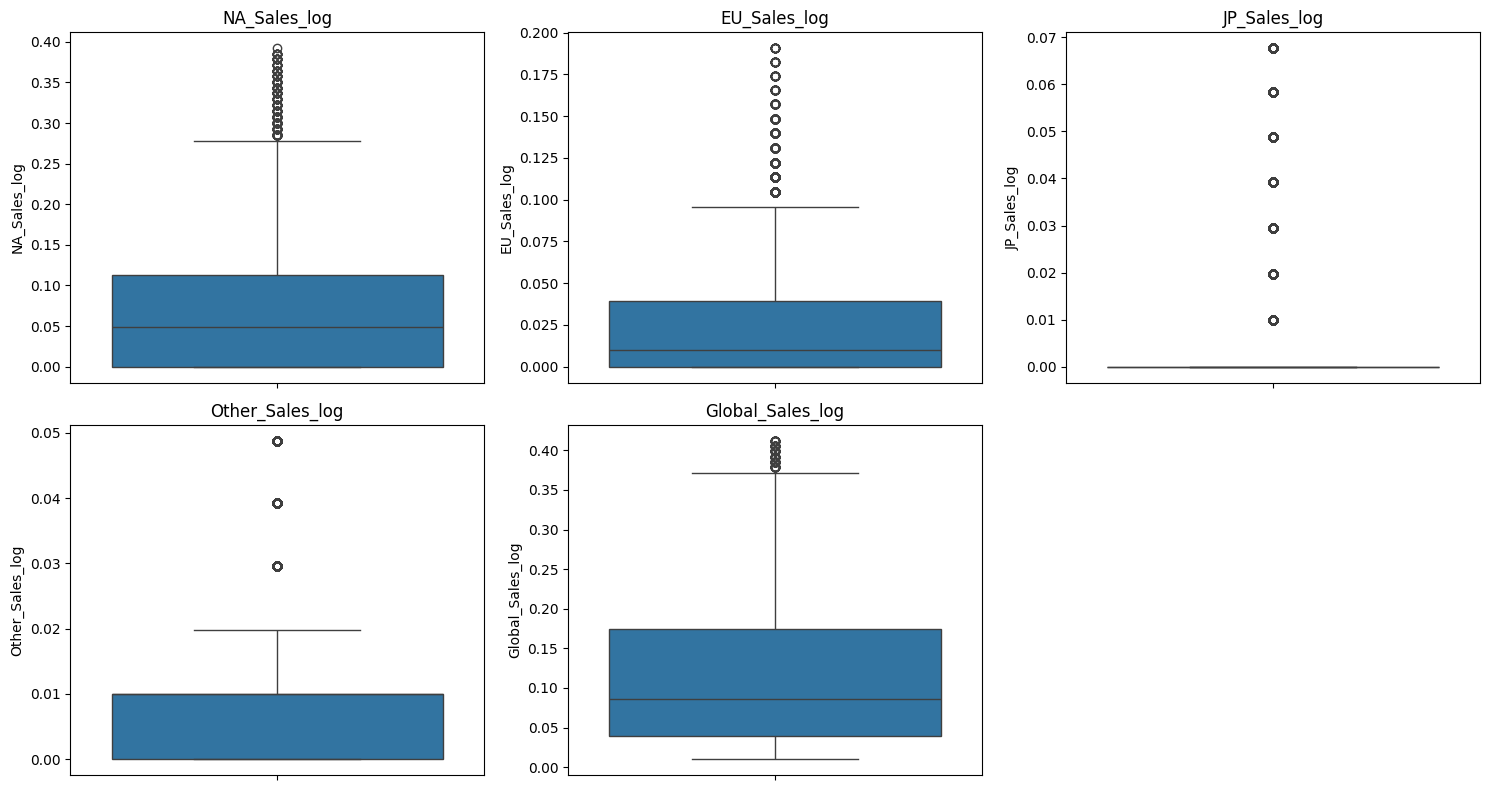

In [ ]:
plt.figure(figsize=(15, 8))

for i, col in enumerate(sales_log_cols, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(y=data[col])
    plt.title(col)

plt.tight_layout()
plt.show()

Ситуация с выбросами стала лучше.
Хотя точки выше новых "усов" все еще есть, их гораздо меньше чем было изначально.

**Вывод:** с помощью ящика с усами обнаружили выбросы в продажах, удалили их с помощью межквартильного размаха.

#### 5 Обработка неправильных типов данных

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10671 entries, 3882 to 16718
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Name              10671 non-null  object 
 1   Platform          10671 non-null  object 
 2   Year_of_Release   10671 non-null  float64
 3   Genre             10671 non-null  object 
 4   Publisher         10671 non-null  object 
 5   NA_Sales          10671 non-null  float64
 6   EU_Sales          10671 non-null  float64
 7   JP_Sales          10671 non-null  float64
 8   Other_Sales       10671 non-null  float64
 9   Global_Sales      10671 non-null  float64
 10  Critic_Score      10671 non-null  float64
 11  Critic_Count      10671 non-null  float64
 12  User_Score        10671 non-null  float64
 13  User_Count        10671 non-null  float64
 14  Developer         10671 non-null  object 
 15  Rating            10671 non-null  object 
 16  NA_Sales_log      10671 non-null  float64


In [ ]:
# object -> int (можно в datetime)
data['Year_of_Release'] = data['Year_of_Release'].astype(int)

In [ ]:
# float -> int (там только целые значения)
int_cols = ['Critic_Score', 'Critic_Count', 'User_Score', 'User_Count']

for col in int_cols:
    data[col] = data[col].astype(int)

In [ ]:
# object -> категориальные
cat_cols = [ 'Platform', 'Genre', 'Rating',  'Name', 'Publisher', 'Developer']

for col in cat_cols:
    data[col] = data[col].astype('category')

In [ ]:
print(data.info())

data.head(1)

<class 'pandas.core.frame.DataFrame'>
Index: 10671 entries, 3882 to 16718
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   Name              10671 non-null  category
 1   Platform          10671 non-null  category
 2   Year_of_Release   10671 non-null  int64   
 3   Genre             10671 non-null  category
 4   Publisher         10671 non-null  category
 5   NA_Sales          10671 non-null  float64 
 6   EU_Sales          10671 non-null  float64 
 7   JP_Sales          10671 non-null  float64 
 8   Other_Sales       10671 non-null  float64 
 9   Global_Sales      10671 non-null  float64 
 10  Critic_Score      10671 non-null  int64   
 11  Critic_Count      10671 non-null  int64   
 12  User_Score        10671 non-null  int64   
 13  User_Count        10671 non-null  int64   
 14  Developer         10671 non-null  category
 15  Rating            10671 non-null  category
 16  NA_Sales_log      10671 

,Name,Platform,Year_of_Release,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,...,Critic_Count,User_Score,User_Count,Developer,Rating,NA_Sales_log,EU_Sales_log,JP_Sales_log,Other_Sales_log,Global_Sales_log
3882,Epic Mickey 2: The Power of Two,X360,2012,Action,Disney Interactive Studios,0.32,0.15,0.0,0.04,0.51,...,35,5,22,Blitz Games Studios,E,0.277632,0.139762,0.0,0.039221,0.41211


**Вывод**: привели все признаки к корректным типам:

- Числовые признаки (`Year_of_Release`, `User_Score`, `Critic_Score`, `Critic_Count`, `User_Count`, `Sales`'ы) были приведены к `float` или `int`.

- Качественные признаки (`Platform`, `Genre`, `Publisher`, `Developer`, `Rating`, `Name`) были приведены к типу `category`.

После этой обработки все данные стали однородными, нет типа `object`.

#### 6 Преобразование качественных признаков

Этих категорий, которые представлены ниже, не так много, как в остальных качественнных признаках


In [ ]:
print(data.Platform.unique())
print(data.Genre.unique())
print(data.Rating.unique())

['X360', '2600', 'DS', 'GC', 'PS', ..., '3DO', 'GG', 'WS', 'PCFX', 'TG16']
Length: 31
Categories (31, object): ['2600', '3DO', '3DS', 'DC', ..., 'WiiU', 'X360', 'XB', 'XOne']
['Action', 'Sports', 'Role-Playing', 'Puzzle', 'Adventure', ..., 'Fighting', 'Shooter', 'Racing', 'Simulation', 'Strategy']
Length: 12
Categories (12, object): ['Action', 'Adventure', 'Fighting', 'Misc', ..., 'Shooter', 'Simulation',
                          'Sports', 'Strategy']
['E', 'Unknown', 'E10+', 'T', 'M', 'EC', 'RP', 'K-A']
Categories (8, object): ['E', 'E10+', 'EC', 'K-A', 'M', 'RP', 'T', 'Unknown']


их можно закодировать.


Если спользовать `One Hot Encoding`, то это приведет к раздуванию датасета.

Используем `LabelEncoder`, в нем каждой категории присваивается число (напр `PS3 - 1, Wii - 2, PC - …`)

In [ ]:
le = LabelEncoder()
for col in ['Platform', 'Genre', 'Rating']:
    data[col + '_code'] = le.fit_transform(data[col])
data.head(2)

,Name,Platform,Year_of_Release,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,...,Developer,Rating,NA_Sales_log,EU_Sales_log,JP_Sales_log,Other_Sales_log,Global_Sales_log,Platform_code,Genre_code,Rating_code
3882,Epic Mickey 2: The Power of Two,X360,2012,Action,Disney Interactive Studios,0.32,0.15,0.0,0.04,0.51,...,Blitz Games Studios,E,0.277632,0.139762,0.0,0.039221,0.41211,28,0,0
3883,Fishing Derby,2600,2007,Sports,Activision,0.48,0.03,0.0,0.01,0.51,...,Unknown,Unknown,0.392042,0.029559,0.0,0.009950,0.41211,0,10,7


Однако качественные признаки `'Name'`, `'Publisher'`, `'Developer'` остались незакодированными.

(`Name` можно было бы и удалить вовсе, так как в моделях вероятнее всего этот признак не будем использовать, но пока пусть остается.)

Так как их уникальных значений очень много, можно закодировать их через `frequency encoder` (не значениями `0,...,k` а их частотой появления в дф, это дает меньше аффекта для линейных моделей, которые могуть считать новые признаки упорядоченными)



In [ ]:
for col in ['Publisher', 'Developer', 'Name']:
    freq = data[col].value_counts() / len(data)
    data[col + '_freq_code'] = data[col].map(freq)
data.head(2)

,Name,Platform,Year_of_Release,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,...,EU_Sales_log,JP_Sales_log,Other_Sales_log,Global_Sales_log,Platform_code,Genre_code,Rating_code,Publisher_freq_code,Developer_freq_code,Name_freq_code
3882,Epic Mickey 2: The Power of Two,X360,2012,Action,Disney Interactive Studios,0.32,0.15,0.0,0.04,0.51,...,0.139762,0.0,0.039221,0.41211,28,0,0,0.011714,0.000562,0.000187
3883,Fishing Derby,2600,2007,Sports,Activision,0.48,0.03,0.0,0.01,0.51,...,0.029559,0.0,0.009950,0.41211,0,10,7,0.059882,0.375129,0.000094


**Вывод**: закодировали качественные признаки методами `Label&Frequency Encoder`

####❓Удалим старые признаки


Так как мы преобразовали исходные признаки (логарифмировали, закодировали категориальные), первоначальные признаки можно убрать из датасета, ибо они по сути дублируют информацию и все равно будут сильно коррелировать с новыми признаками. Однако потом их нельзя будет использовать для визуализации.

In [ ]:
data.drop(columns=['Name', 'Platform', 'Genre', 'Publisher','NA_Sales',
                   'EU_Sales','JP_Sales','Other_Sales','Global_Sales','Developer',
                   'Rating'], inplace=True)

### b) Доп предобработка для практической работы №2

зададим классы внутри Global_Sales_log наиболее простым способом.

In [ ]:
# Порог по медиане
threshold = data["Global_Sales_log"].median()

# Новый таргет для классификации
data["Sales_Class"] = (data["Global_Sales_log"] >= threshold).astype(int)
data["Sales_Class"].value_counts()

,count
Sales_Class,
1,5341
0,5330


**Проверка на дисбаланс классов**

In [ ]:
display(data['Sales_Class'].value_counts())
print(f'Число индивидов в малочисленном классе:', data['Sales_Class'].value_counts().min())
print(f'Число индивидов в многочисленном классе:', data['Sales_Class'].value_counts().max())

,count
Sales_Class,
1,5341
0,5330


Число индивидов в малочисленном классе: 5330
Число индивидов в многочисленном классе: 5341


<!-- Видим, что есть сильный дисбаланс классов.  -->
Видим, что классы сбалансированы.

**Проверка на корреляцию признаков**

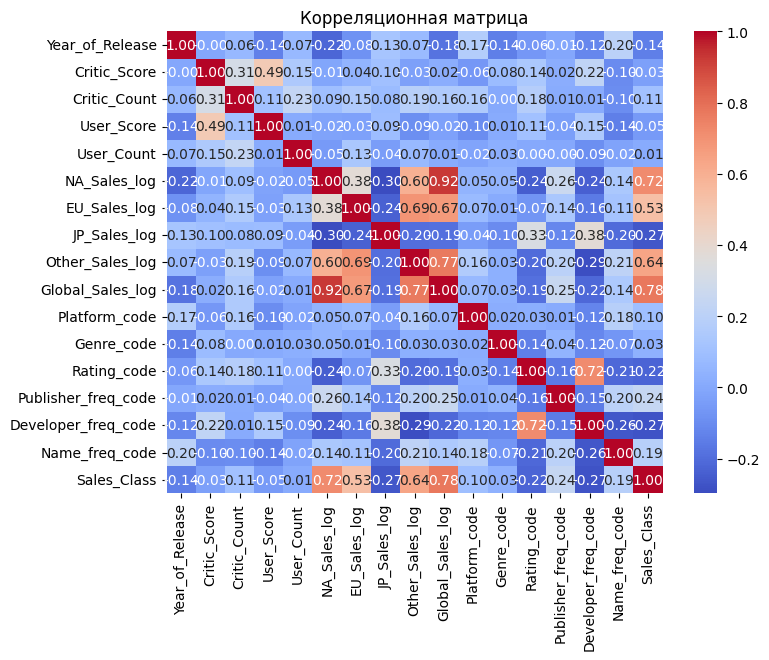

In [ ]:
# 1.Корреляционная матрица
external_corr = data.corr()
plt.figure(figsize=(8, 6))
sns.heatmap(external_corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Корреляционная матрица')
plt.show()

Видим, что есть:
- корреляция у продаж (`Global_Sales` с `NA_Sales` особенно сильная(0,92) и с продажами в остальных регионах)
- рейтинг и разработчик (0,72)
- оценки игроков и критиков (0,49)
- отрицательные корреляции отсутствуют

Корреляция с целевым признаком(`Sales_Class`):
- высокая положительная корреляция с продажами
- чуть менее сильная с продажами в Японии (возможно, из-за не такого сильного разброса значений внутри признака).

<!-- Корреляция с целевым признаком(`Genre_code`):
ни один из представленных признаков особо сильно не коррелирует, примерно везде значения колеблятся около 0.  -->


**Вывод:** классы сбалансированные, по таргету корреляция положительная, особенно высокая с признаками, связанными с продажами(оно и логично).

<!-- низкая.  -->

### c) Частичный повтор работы №1

#### 7 Разделение выборки (на тренировочную, тестовую, валидационную)

Разделим выборку в соотношении `60/20/20`




In [ ]:
# X — все признаки,
# y — целевая переменная #(например, Global_Sales_log)
# # При интерпертации результатов надо будет вернуться (y_pred_real = np.expm1(y_pred_log))
X = data.drop(columns=['Sales_Class'])
y = data['Sales_Class']

# сначала выделяем тренировочную 60% и временную 40% (для валидации и теста)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.4, random_state=42
)

# затем делим оставшиеся 40% пополам: 20% валидация, 20% тест
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42
)

# проверим размеры выборок
print("Train:", X_train.shape, "Validation:", X_val.shape, "Test:", X_test.shape)

Train: (6402, 16) Validation: (2134, 16) Test: (2135, 16)


или в процентах:

In [ ]:
n_total = len(data)
print(f"Train: {X_train.shape[0]} ({X_train.shape[0]/n_total*100:.1f}%)")
print(f"Validation: {X_val.shape[0]} ({X_val.shape[0]/n_total*100:.1f}%)")
print(f"Test: {X_test.shape[0]} ({X_test.shape[0]/n_total*100:.1f}%)")

Train: 6402 (60.0%)
Validation: 2134 (20.0%)
Test: 2135 (20.0%)


как и ожидалось.

**Вывод**: При `random_state=42` разделили выборку на три части:

- Тренировочная выборка (`X_train, y_train`) — 60% данных (используется для обучения моделей)

- Валидационная выборка (`X_val, y_val`)— 20% данных (используется для подбора гиперпараметров и контроля переобучения)

- Тестовая выборка (`X_test, y_test`)— 20% данных (используется для финальной оценки качества модели)

#### 8 Стандартизация данных

Цель — преобразовать исходный набор в новый со средним значением равным 0 и стандартным отклонением равным 1.

Стандартизация нужна, чтобы все числовые признаки имели одинаковый масштаб. Это важно для некоторых чувствительных к нему моделей.

У нас, например, оценки критиков(0-100) и игроков(0-10) меняются в разных масштабах.

Стандартизуем числовые признаки.

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10671 entries, 3882 to 16718
Data columns (total 17 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Year_of_Release      10671 non-null  int64  
 1   Critic_Score         10671 non-null  int64  
 2   Critic_Count         10671 non-null  int64  
 3   User_Score           10671 non-null  int64  
 4   User_Count           10671 non-null  int64  
 5   NA_Sales_log         10671 non-null  float64
 6   EU_Sales_log         10671 non-null  float64
 7   JP_Sales_log         10671 non-null  float64
 8   Other_Sales_log      10671 non-null  float64
 9   Global_Sales_log     10671 non-null  float64
 10  Platform_code        10671 non-null  int64  
 11  Genre_code           10671 non-null  int64  
 12  Rating_code          10671 non-null  int64  
 13  Publisher_freq_code  10671 non-null  float64
 14  Developer_freq_code  10671 non-null  float64
 15  Name_freq_code       10671 non-null  f

In [ ]:
scaler = StandardScaler()

# выбираем признаки для стандартизации
num_features = [
    'Year_of_Release',
    'Critic_Score',
    'Critic_Count',
    'User_Score',
    'User_Count',
    'NA_Sales_log',
    'EU_Sales_log',
    'Other_Sales_log'
]

# fit на train
scaler.fit(X_train[num_features])

# трансформируем train, test, val
X_train[num_features] = scaler.transform(X_train[num_features])
X_test[num_features] = scaler.transform(X_test[num_features])
X_val[num_features] = scaler.transform(X_val[num_features])

***Вывод***: стандартизировали числовые признаки (`'Year_of_Release','Critic_Score','Critic_Count',
'User_Score',
'User_Count',
'NA_Sales_log',
'EU_Sales_log',
'Other_Sales_log'`) с помощью `StandardScaler`

### **Вывод:**

предобработали данные для задач практической работы №2.
- сделали новый таргет для классификации `Sales_Class`(класс 1\0-выше\ниже медианы)
- проверили на дисбаланс классов - данные сбалансированы
- проверили наличие корреляций меж признаков и признаков с таргетом (сильная корреляция с продажами в регионах)

## 3 Логистическая регрессия (биномиальная)


<!-- Использовать логистическую регрессию  (достаточно одного метода, но необходимо обосновать почему именно его). -->

**Обосноание выбора метода:**

Для этого пункта я выбрала ***биномиальную*** логистическую регрессию, т к при разбиении мы делили именно на два класса(с продажами выше и ниже медианы).

Это самая простая из ее типов, а еще не придется строить 3 раза однотипную матрицу ошибок. (̶л̶е̶н̶ь̶-̶д̶в̶и̶г̶а̶т̶е̶л̶ь̶.̶.̶.̶)̶

In [ ]:
# Биномиальная логистическая регрессия
blr = LogisticRegression(max_iter=2000, # blr сходится и за 200 шагов, а svm-ы далее с 2000
                         random_state=42
                        )
blr.fit(X_train, y_train)
y_pred_blr = blr.predict(X_test)

blr_acc = accuracy_score(y_test, y_pred_blr) * 100
blr_f1 = f1_score(y_test, y_pred_blr) * 100
print(f"Accuracy: {blr_acc:.2f}%")
print(f"F1-score: {blr_f1:.2f}%")
print(classification_report(y_test, y_pred_blr, digits=3))

Accuracy: 98.22%
F1-score: 98.23%
              precision    recall  f1-score   support

           0      0.978     0.986     0.982      1059
           1      0.986     0.979     0.982      1076

    accuracy                          0.982      2135
   macro avg      0.982     0.982     0.982      2135
weighted avg      0.982     0.982     0.982      2135



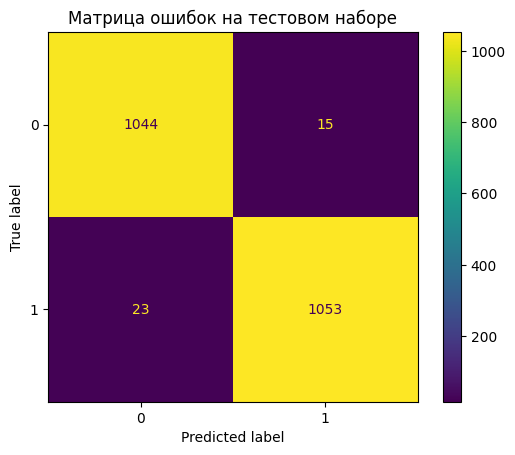

              precision    recall  f1-score   support

           0      0.978     0.986     0.982      1059
           1      0.986     0.979     0.982      1076

    accuracy                          0.982      2135
   macro avg      0.982     0.982     0.982      2135
weighted avg      0.982     0.982     0.982      2135



In [ ]:
# Матрица ошибок
cm = confusion_matrix(y_test, y_pred_blr, labels=[0,1])

# Визуализация
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0,1])
disp.plot(values_format='d')
plt.title("Матрица ошибок на тестовом наборе")
plt.show()

# Отчёт
print(classification_report(y_test, y_pred_blr, digits=3))

доля верных предсказаний классификатором TP=1053 и TN=1044 высокая. доля ошибок первого рода FN=23 и второго рода FP=15 низкая.

**Вывод:** при стандартной биномиальной логистческой регрессии получилось достигнуть исключительно хорошего качества предсказаний (и даже сойтись за относительно малое число шагов (даже при 200 итерациях-метод уже сходится, 2000 стоит для сравнения методов)).

## 4 Метод опорных векторов (SVC)

<!-- Использовать методы опорных векторов (достаточно выбор одного ядра, но обосновать почему именно его – использование всех ядер и описание выводов по ним будет считать как доп. задание и возможно получить до 2 до баллов). -->

**Обоснование выбора метода:**

У метода SVM есть два типа реализации - SVC(для классификации) и SVR(для регрессии). Так как выше мы решали задачу классификации `Global_Class`, считаю разумным и дальше ее решать, что бы сравнить два подхода в этой в работе.
Но, естественно, можно решать и наиболее естественную задачу для моих данных - задачу регресси `Global_Sales`.

### 1 `rbf`

**Обоснование выбора ядра:** как было сказано на практике, радиально-базисное самое популярное, универсально(может в нелинейность) и "точнее" для большинства практических случаев. Если бы надо было использовать только один тип ядра, ввиду ограниченности ресурсов, например - выбор пал бы на это ядро.

In [ ]:
# 1. SVC + rbf
svc_rbf = SVC(kernel='rbf', C=1.0, max_iter=2000, probability=False, random_state=42)
svc_rbf.fit(X_train, y_train)

y_pred_svc_rbf = svc_rbf.predict(X_test)

# Считаем метрики качества
print(f"Accuracy: {accuracy_score(y_test, y_pred_svc_rbf):.3f}")
print(f"F1: {f1_score(y_test, y_pred_svc_rbf):.3f}")

# Отчёт
print(classification_report(y_test, y_pred_svc_rbf, digits=3))

Accuracy: 0.958
F1: 0.959
              precision    recall  f1-score   support

           0      0.958     0.958     0.958      1059
           1      0.959     0.958     0.959      1076

    accuracy                          0.958      2135
   macro avg      0.958     0.958     0.958      2135
weighted avg      0.958     0.958     0.958      2135



In [ ]:
# универсальная функция для визуализации, похожая на ту что в практике 5
def plot_svc_with_margin(clf, Xs, y, title="SVC with margin", feature_names=None):
    """Рисует разделяющую гиперплоскость, margin и точки"""
    Xarr = Xs.values if hasattr(Xs, "values") else np.asarray(Xs)
    if feature_names is None:
        if hasattr(Xs, "columns"):
            feature_names = list(Xs.columns[:2])
        else:
            feature_names = ["x1", "x2"]

    # сетка для фона
    x_min, x_max = Xarr[:, 0].min() - 0.5, Xarr[:, 0].max() + 0.5
    y_min, y_max = Xarr[:, 1].min() - 0.5, Xarr[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 600),
                         np.linspace(y_min, y_max, 600))
    grid = np.c_[xx.ravel(), yy.ravel()]
    Z = clf.decision_function(grid).reshape(xx.shape)

    # график
    plt.figure(figsize=(6.2, 5.2))
    plt.contourf(xx, yy, Z, levels=30, alpha=0.25)
    plt.contour(xx, yy, Z, levels=[0], colors='k', linewidths=2)
    plt.contour(xx, yy, Z, levels=[-1, 1], colors='k', linestyles='--', linewidths=1.3)

    scatter = plt.scatter(Xarr[:, 0], Xarr[:, 1], c=y, s=28,
                          edgecolor='k', alpha=0.9, cmap="coolwarm")

    # опорные вектора
    sv = clf.support_vectors_
    plt.scatter(sv[:, 0], sv[:, 1], s=80, facecolors='none',
                edgecolors='r', linewidths=1.5, label='support vectors')

    plt.xlabel(feature_names[0])
    plt.ylabel(feature_names[1])
    plt.title(title)
    plt.legend(loc='upper right')
    plt.tight_layout()
    plt.show()


def train_and_plot_svc(X, y, kernel="linear", use_pca=True, C=1.0, gamma="scale", degree=3):
    """Обучает SVC на X,y с ядром kernel и строит график в 2D (применяя PCA если признаков не 2)"""
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    if use_pca:
        pca = PCA(n_components=2)
        X_plot = pca.fit_transform(X_scaled)
        feature_names = ["PC1", "PC2"]
    else:
        X_plot = X_scaled[:, :2]
        feature_names = list(X.columns[:2])

    clf = SVC(kernel=kernel, C=C, gamma=gamma, degree=degree)
    clf.fit(X_plot, y)

    plot_svc_with_margin(clf, X_plot, y,
                         title=f"SVC (kernel={kernel})",
                         feature_names=feature_names)

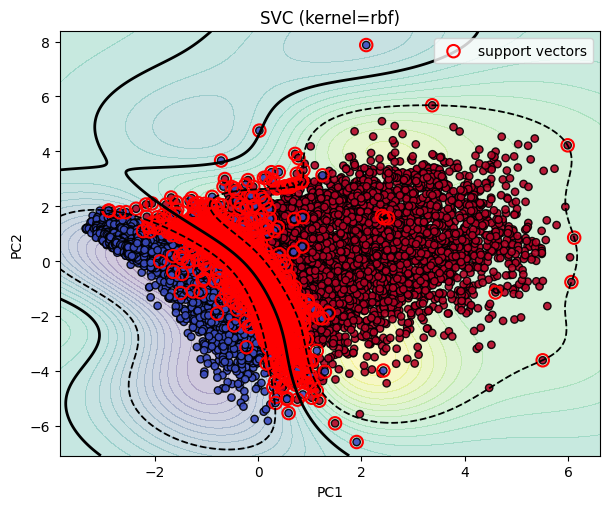

In [ ]:
train_and_plot_svc(X=data.drop(columns=["Sales_Class"]),
                   y=data["Sales_Class"],
                   kernel="rbf",
                   use_pca=True)  # True = PCA, False = выбрать первые 2 признака

Получилось выделить две округлые области. Вторая сильно больше. Причем некоторые точки синего класса (верхний правый угол) удается верно классифицировать.

***Вывод:*** выбор такого ядра дало хорошие результаты (acc&F1 ~ 95,8%), даже со стандартными гиперпараметрами.

### ДОП: применение всех ядер

#### 2 `linear`

Второй по популярности вид ядра "по умолчанию" - линейное. Оно быстро работает, но хорошо будет работать только в случае линейной разделимости данных.

In [ ]:
# 2. SVC + linear kernel
svc_linear = SVC(kernel='linear',max_iter=2000, C=1.0, probability=False, random_state=42)
svc_linear.fit(X_train, y_train)

y_pred_svc_lin = svc_linear.predict(X_test)

# Считаем метрики качества
print(f"Accuracy: {accuracy_score(y_test, y_pred_svc_lin):.3f}")
print(f"F1: {f1_score(y_test, y_pred_svc_lin):.3f}")

# Отчёт
print(classification_report(y_test, y_pred_svc_lin, digits=3))

Accuracy: 0.962
F1: 0.962
              precision    recall  f1-score   support

           0      0.964     0.959     0.962      1059
           1      0.960     0.965     0.962      1076

    accuracy                          0.962      2135
   macro avg      0.962     0.962     0.962      2135
weighted avg      0.962     0.962     0.962      2135



/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=2000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


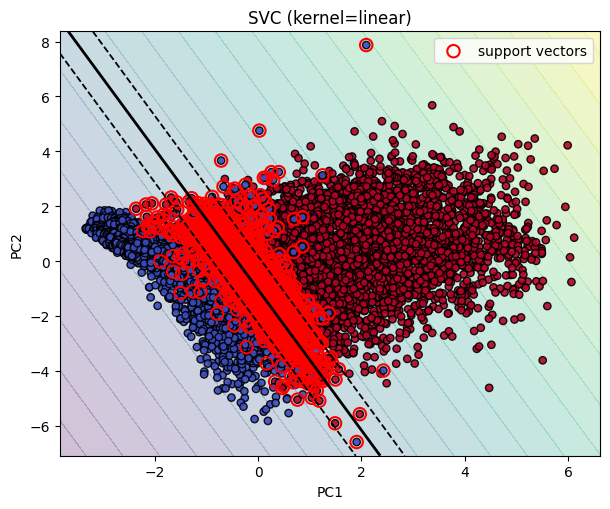

In [ ]:
train_and_plot_svc(X=data.drop(columns=["Sales_Class"]),
                   y=data["Sales_Class"],
                   kernel="linear",
                   use_pca=True)  # True = PCA, False = выбрать первые 2 признака

Вновь выделили две области, но линией.

***Вывод*** после применения ядра другого типа: значение точности выросло на 1%, F1 немного ниже, но в целом так же показывает хороший результат.

#### 3 `poly`

Проверим работу с полиномиальным ядром 3 степени(по умолчанию).

In [ ]:
# 3. SVC + poly
svc_poly = SVC(kernel='poly',max_iter=2000, C=1.0, probability=False, random_state=42) # По умолчанию степень = 3
svc_poly.fit(X_train, y_train)

y_pred_svc_poly = svc_poly.predict(X_test)

# Считаем метрики качества
print(f"Accuracy: {accuracy_score(y_test, y_pred_svc_poly):.3f}")
print(f"F1: {f1_score(y_test, y_pred_svc_poly):.3f}")

# Отчёт
print(classification_report(y_test, y_pred_svc_poly, digits=3))

/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=2000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


Accuracy: 0.929
F1: 0.925
              precision    recall  f1-score   support

           0      0.886     0.983     0.932      1059
           1      0.981     0.875     0.925      1076

    accuracy                          0.929      2135
   macro avg      0.934     0.929     0.929      2135
weighted avg      0.934     0.929     0.929      2135



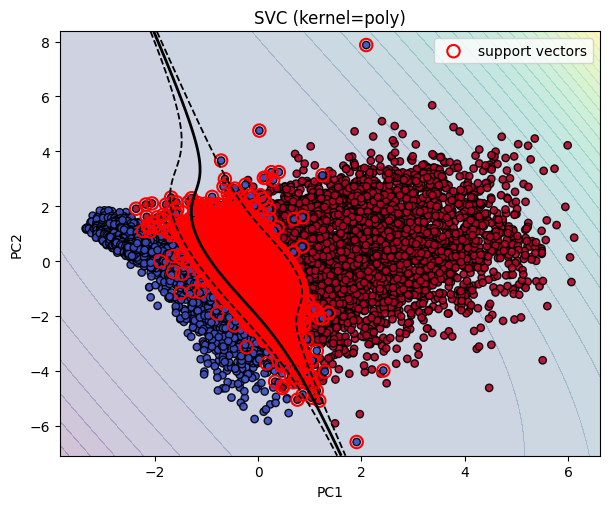

In [ ]:
train_and_plot_svc(X=data.drop(columns=["Sales_Class"]),
                   y=data["Sales_Class"],
                   kernel="poly",
                   use_pca=True)  # True = PCA, False = выбрать первые 2 признака

График похож на линейный, но более "выпуклый". отличия в виде зазора.

***Вывод*** после применения ядра другого типа: значения метрик, по сравнению с базовой моделью(`rbf`) уменьшились на 3%. Так же чувчтвуется уменьшение точности по 0 классу.

#### 4 `sigmoid`

Проверим "самое красивое" но не самое универсальное ядро - сигмоидальное.

In [ ]:
# 4. SVC + sigmoid
svc_sigmoid = SVC(kernel='sigmoid',max_iter=2000, C=1.0, probability=False, random_state=42)
svc_sigmoid.fit(X_train, y_train)

y_pred_svc_sigmoid = svc_sigmoid.predict(X_test)

# Считаем метрики качества
print(f"Accuracy: {accuracy_score(y_test, y_pred_svc_sigmoid):.3f}")
print(f"F1: {f1_score(y_test, y_pred_svc_sigmoid):.3f}")

# Отчёт
print(classification_report(y_test, y_pred_svc_sigmoid, digits=3))

Accuracy: 0.571
F1: 0.567
              precision    recall  f1-score   support

           0      0.566     0.585     0.575      1059
           1      0.577     0.558     0.567      1076

    accuracy                          0.571      2135
   macro avg      0.572     0.572     0.571      2135
weighted avg      0.572     0.571     0.571      2135



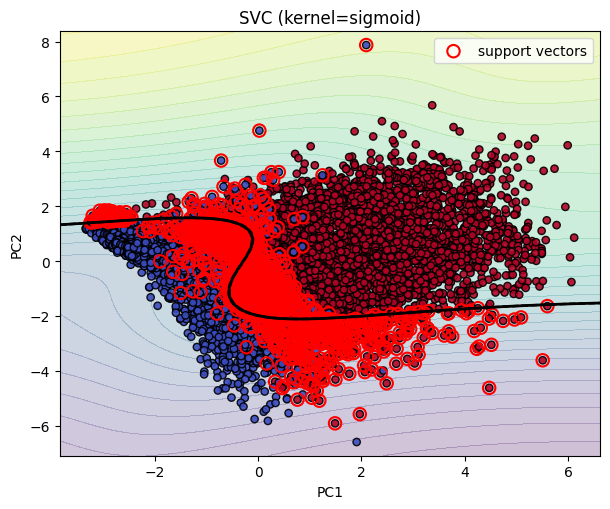

In [ ]:
train_and_plot_svc(X=data.drop(columns=["Sales_Class"]),
                   y=data["Sales_Class"],
                   kernel="sigmoid",
                   use_pca=True)  # True = PCA, False = выбрать первые 2 признака

***Вывод*** после применения ядра другого типа: с сигмоидой все стало совсем плохо, значения метрик упали почти на 40%. Чдро совсем не подходит для наших данных.

## Общий вывод по ядрам

**Вывод:** Проведённое сравнение различных ядер SVC показало:

1. `RBF` обеспечивает высокую точность (~95,8%) даже без настройки гиперпараметров, что подтверждает её универсальность.

2. `Linear` показало чуть лучшие результаты (+1%), что указывает на то, что данные в целом линейно разделимы, и линейное ядро оказалось оптимальным.

3. `Poly` ухудшило метрики на ~3% по сравнению с RBF, что свидетельствует о том, что дополнительная полиномиальная сложность не нужна для этой задачи.

4. `Sigmoid` показало крайне низкие результаты (метрики упали почти на 40%), что делает это ядро непригодным для текущей бинарной классификации.

⇒ для данной задачи бинарной классификации наиболее подходящим является *линейное* ядро, при этом RBF остаётся хорошей альтернативой для учета возможной нелинейности. Poly и Sigmoid нецелесообразны.

## 5 Подбор гиперпараметров

<!-- Ко всем методам необходимо попробовать подобрать вручную гиперпараметры, можно просто поменять и посмотреть результат. Это должен быть отдельный блок кода, где Вы поменяли параметры модели, получили метрику качества и сделали выводы почему точность изменилась или почему не изменилась. -->

### Для логистической регрессии:

#### Перебор `C`

Вручную переберем гиперпараметр регуляризации `C` для метода бинарной логистической регрессии. (ее тип - l2 по умолчанию)

In [ ]:
# Напомню, стандартная модель в п.3 выглядела так:
# blr = LogisticRegression(max_iter=200, random_state=42)
# blr.fit(X_train, y_train)
# y_pred_blr = blr.predict(X_test)

params = {
    "Сильная регуляризация (C=0.001)": 0.001,
    "Стандартная (см п.3)": 1.0,
    "Слабая регуляризация (C=1000)": 1000
}

for desc, C_value in params.items():
    blr = LogisticRegression(C=C_value, max_iter=2000, random_state=42)
    blr.fit(X_train, y_train)
    y_pred = blr.predict(X_test)

    print(f"\n ---- (бинарная) Логистическая регрессия  ({desc}) ----")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("F1-score:", f1_score(y_test, y_pred))


 ---- (бинарная) Логистическая регрессия  (Сильная регуляризация (C=0.001)) ----
Accuracy: 0.922248243559719
F1-score: 0.919260700389105

 ---- (бинарная) Логистическая регрессия  (Стандартная (см п.3)) ----
Accuracy: 0.9822014051522249
F1-score: 0.9822761194029851

 ---- (бинарная) Логистическая регрессия  (Слабая регуляризация (C=1000)) ----
Accuracy: 0.9995316159250586
F1-score: 0.9995355318160706


***Вывод:***
Для сильной регуляризации (`C=0.001`) Accuracy составила 0.922, F1-score — 0.919, что ниже стандартного уровня.
Стандартная регуляризация (`C=1`) дала Accuracy 0.982 и F1-score 0.982, показатели находятся на высоком уровне.
Слабая регуляризация (`C=1000`) обеспечила максимальные метрики: Accuracy 0.9995, F1-score 0.9995.

> увеличение C повышает Accuracy и F1-score, уменьшение — снижает их.

### Для SVM:

#### Эксперименты с штрафом ошибки `C` и видом границы `gamma`

Зафиксируем ядро rbf и переберем пвраметры C и gamma

In [ ]:
params = [
    {"C": 0.1, "gamma": 0.1},
    {"C": 1,   "gamma": 0.1},
    {"C": 10,  "gamma": 0.1},
    {"C": 1,   "gamma": 1},
    {"C": 10,  "gamma": 1},
]

for p in params:
    svc = SVC(kernel='rbf', C=p["C"], gamma=p["gamma"],max_iter=2000, random_state=42)
    svc.fit(X_train, y_train)
    y_pred = svc.predict(X_test)

    print(f"\n ---- SVC (C={p['C']}, gamma={p['gamma']}) ---- ")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("F1-score:", f1_score(y_test, y_pred))

/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=2000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(



 ---- SVC (C=0.1, gamma=0.1) ---- 
Accuracy: 0.9152224824355972
F1-score: 0.9174646602827178


/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=2000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(



 ---- SVC (C=1, gamma=0.1) ---- 
Accuracy: 0.9391100702576113
F1-score: 0.9400921658986175


/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=2000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(



 ---- SVC (C=10, gamma=0.1) ---- 
Accuracy: 0.9498829039812646
F1-score: 0.9503480278422274


/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=2000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(



 ---- SVC (C=1, gamma=1) ---- 
Accuracy: 0.868384074941452
F1-score: 0.880476393024245


/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=2000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(



 ---- SVC (C=10, gamma=1) ---- 
Accuracy: 0.8744730679156909
F1-score: 0.8843830888697153


***Вывод:***
При фиксированном малом `gamma`=0.1 увеличение `C` от 0.1 до 10 последовательно повышает Accuracy и F1-score:
- C=0.1: Accuracy 0.915, F1 0.917
- C=1: Accuracy 0.939, F1 0.940
- C=10: Accuracy 0.948, F1 0.949

При увеличении gamma=1 показатели снижаются, даже при больших значениях C:
- C=1: Accuracy 0.866, F1 0.879
- C=10: Accuracy 0.876, F1 0.886

Однако методы не сошлись, вероятно при увеличении числа шагов показатели бы возросли.

> Итог: метрики лучше при умеренном gamma (0.1) и увеличении C. Высокие значения gamma ухудшают качество классификации, а влияние C проявляется сильнее при небольшом gamma.

#### Перебор `kernel`

- так же, перебор ядер из прошлого пункта, тоже является ручным перебором гиперпараметров модели SVC.

(см. п. 4)

### **Вывод:**
Изменение гиперпараметров моделей позволяет влиять на точность и F1 меру. Подбор оптимальных значений параметров улучшает качество классификации и помогает добиться лучших предсказаний. Для обеих моделей наблюдается зависимость метрик от выбранных настроек.

## 6 Метрики качества

<!-- Основные метрики качества проверки: F1-score (по обоим/всем классам) и Accuracy, можно использовать больше, если хочется. -->

Метрики для моделей были рассчитаны сразу после их работы (предсказаний). Для удобства проверки, перенесем все полученные метрики в блок ниже.

In [ ]:
# Словарь предсказаний моделей: ключ - название для вывода, значение - предсказания
models_preds = {
    "blr": y_pred_blr,
    "SVC (RBF)": y_pred_svc_rbf,
    "SVC (linear)": y_pred_svc_lin,
    "SVC (poly)": y_pred_svc_poly,
    "SVC (sigmoid)": y_pred_svc_sigmoid
}

for name, y_pred in models_preds.items():
    print(f"\n ---- {name} ---- ")
    print(f"Accuracy: {accuracy_score(y_test, y_pred):.3f}")
    print(f"F1-score: {f1_score(y_test, y_pred):.3f}")
    print(classification_report(y_test, y_pred, digits=3))


 ---- blr ---- 
Accuracy: 0.982
F1-score: 0.982
              precision    recall  f1-score   support

           0      0.978     0.986     0.982      1059
           1      0.986     0.979     0.982      1076

    accuracy                          0.982      2135
   macro avg      0.982     0.982     0.982      2135
weighted avg      0.982     0.982     0.982      2135


 ---- SVC (RBF) ---- 
Accuracy: 0.958
F1-score: 0.959
              precision    recall  f1-score   support

           0      0.958     0.958     0.958      1059
           1      0.959     0.958     0.959      1076

    accuracy                          0.958      2135
   macro avg      0.958     0.958     0.958      2135
weighted avg      0.958     0.958     0.958      2135


 ---- SVC (linear) ---- 
Accuracy: 0.962
F1-score: 0.962
              precision    recall  f1-score   support

           0      0.964     0.959     0.962      1059
           1      0.960     0.965     0.962      1076

    accuracy        

**Вывод:** наилучшие результаты достигаются с линейным ядром SVC и логистической регрессией, RBF и полиномиальное остаётся хорошим вариантом, а сигмоидное ядро показывает существенно худший результат.

## 7 Выводы

<!-- Сделать понятные, четкие выводы по каждому алгоритму, по каждому использованному методу (name.info() и тд можно не комментировать, главное сделать выводы, связанные с новым методом) -->

> Выводы по каждому из методов, были представлены сразу по мере их применения. Приведем обобщения по всей работе и наиболее яркие из них здесь.

**Вывод:**
- Говоря о том, какой из методов справился с классификацией лучше, то выйграл, метод *логистической регрессии*, однако его различие с SVC+linear составило всего 2%.

- Во всех моделях *лучше классифицируются обьекты 1 класса* (прибыльные). Можно было бы вспомнить, что в этом классе на целый 1 индивид больше, но это не должно сильно влиять на картину в совокупности.

- Логистическая регрессия *может сойтись и за меньшее число итераций*(напр, 200). Некоторые модели SVC не сходились при варьировании гиперпараметров.

⇒ для данной задачи бинарной классификации наиболее подходящим является *линейное* ядро, при этом RBF остаётся хорошей альтернативой для учета возможной нелинейности. Poly и Sigmoid нецелесообразны.